<a href="https://colab.research.google.com/github/dhruv0987/ML-LIVE-CLASS/blob/main/live.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total Samples: 1000
Nominal Runs: 977
Abort Runs: 23

Model Performance Report:
              precision    recall  f1-score   support

 Nominal (0)       1.00      1.00      1.00       198
   Abort (1)       1.00      1.00      1.00         2

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

----------------------------------------
REAL-TIME ENGINE STATUS:
🚨 PREDICTIVE ABORT TRIGGERED! (Confidence: 92.0%)
----------------------------------------


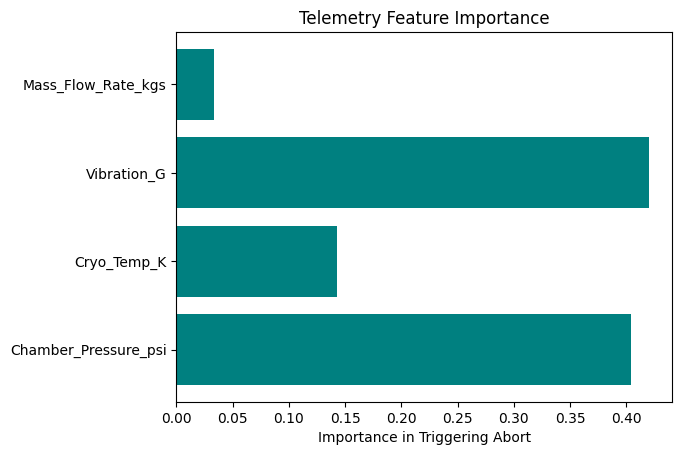

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Phase 1: Generate Synthetic Static-Fire Test Data
# ---------------------------------------------------------
np.random.seed(42)
num_samples = 1000

# Simulating telemetry readings
chamber_pressure = np.random.normal(1500, 100, num_samples) # psi
cryo_propellant_temp = np.random.normal(90, 5, num_samples) # Kelvin (e.g., LOX)
vibration = np.random.normal(2.5, 0.8, num_samples) # G-forces
mass_flow_rate = np.random.normal(500, 20, num_samples) # kg/s

df = pd.DataFrame({
    'Chamber_Pressure_psi': chamber_pressure,
    'Cryo_Temp_K': cryo_propellant_temp,
    'Vibration_G': vibration,
    'Mass_Flow_Rate_kgs': mass_flow_rate
})

# Define the "Abort" logic (Creating the labels for our ML model to learn)
# An abort happens if conditions are too extreme, or if combinations are dangerous
def determine_abort(row):
    if row['Chamber_Pressure_psi'] > 1750 or row['Chamber_Pressure_psi'] < 1200:
        return 1
    if row['Cryo_Temp_K'] > 105:
        return 1
    if row['Vibration_G'] > 4.5:
        return 1
    # Complex interaction: High pressure AND high vibration
    if row['Chamber_Pressure_psi'] > 1650 and row['Vibration_G'] > 3.5:
        return 1
    return 0

df['Abort_Triggered'] = df.apply(determine_abort, axis=1)

print(f"Total Samples: {len(df)}")
print(f"Nominal Runs: {len(df[df['Abort_Triggered'] == 0])}")
print(f"Abort Runs: {len(df[df['Abort_Triggered'] == 1])}\n")

# ---------------------------------------------------------
# Phase 2: Train the Predictive Model
# ---------------------------------------------------------
X = df.drop('Abort_Triggered', axis=1)
y = df['Abort_Triggered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Using Random Forest for robust classification
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
predictions = model.predict(X_test)
print("Model Performance Report:")
print(classification_report(y_test, predictions, target_names=['Nominal (0)', 'Abort (1)']))

# ---------------------------------------------------------
# Phase 3: Real-Time Engine Forecast (The Live Sandbox)
# ---------------------------------------------------------
# Edit these values with your data to see how the model reacts!
current_telemetry = pd.DataFrame({
    'Chamber_Pressure_psi': [1680],  # Slightly elevated
    'Cryo_Temp_K': [95],             # Normal
    'Vibration_G': [2.8],            # Getting rough
    'Mass_Flow_Rate_kgs': [505]      # Normal
})

# Predict outcome and get probabilities
predicted_state = model.predict(current_telemetry)[0]
abort_probability = model.predict_proba(current_telemetry)[0][1]

print("-" * 40)
print("REAL-TIME ENGINE STATUS:")
if predicted_state == 1:
    print(f"🚨 PREDICTIVE ABORT TRIGGERED! (Confidence: {abort_probability*100:.1f}%)")
else:
    print(f"✅ NOMINAL. (Risk of abort: {abort_probability*100:.1f}%)")
print("-" * 40)

# Optional: Visualize which sensors the model thinks are most important
importances = model.feature_importances_
plt.barh(X.columns, importances, color='teal')
plt.xlabel("Importance in Triggering Abort")
plt.title("Telemetry Feature Importance")
plt.show()